# <center> **Tema 2 - Ecuaciones Lineales y No Lineales** </center>

In [55]:
import numpy as np
import matplotlib as plt
import sympy

A menudo queremos resolver ecuaciones de la forma: $f(x) = 0$

## <center>**2.1 - Metodo de la Bisección**</center>

### Derivación

**Requisitos:**
 - Función Continua f(x)
 - Intervalo inicial [a,b] donde $f(a) · f(b) < 0$

Siempre converge, aunque es relativamente lento.  
Basado en el teorema de Bolzano

**Proceso Iterativo:**  
    1. Calcular Punto Medio. $x_0 = \frac{a + b}{2}$  
    2. Calcular Nuevo Intervalo  
        - Si $f(a) · f(x_0) < 0$, el nuevo intervalo es [a,$x_0$]  
        - Si $f(b) · f(x_0) < 0$, el nuevo intervalo es [$x_0$,b]  
        - Si $f(x_0) = 0$, $x_0$ es la raiz    

**Criterio de Parada:** Necesitamos detener las iteraciones cuando el valor este lo suficientemente cerca de la raiz  
    - **Criterio Principal:** $|x_k - x_{k-1}| < $ TOL, donde TOL es una tolerancia predefinida  
    - **Valor de la función:** $|f(x_k)| < TOL_f$  
    - **Longitud del Intervalo (Solo Bisección):** $|b-a| < TOL_{interval}$

Para metodos que no converjan siempre, hay que fijar un numero maximo de iteraciones

<!-- **Criterio de Parada: ** Necesitamos detener las iteraciones cuando el valor de $x_k$ -->

**Algoritmo:**

In [56]:
def biseccion(f,a,b,tol=1.e-6,maxiter=20,verbose=False):
    k = 0
    fa,fb = f(a),f(b)
    c = None
    assert fa*fb < 0, "No se puede aplicar biseccion"

    if verbose:
        print(f"{'k':>3} {'a':>12} {'b':>12} {'c':>12} {'f(c)':>12} {'error':>12}")
        
    while k < maxiter:
        
        c = (a+b)/2
        fc = f(c)
        
        error = b-a
        
        if verbose:
            print(f"{k:3d} {a:12.6e} {b:12.6e} {c:12.6e} {fc:12.6e} {error:12.6e}")
        
        if (fa*fc < 0): 
            b,fb = c,fc
        elif (fb*fc < 0):
            a,fa = c,fc
        else:
            break  
        
        if np.abs(error) < tol:
            break
        
        k += 1
        
    else:
        print("Numero maximo de iteraciones alcanzadas")
        
    return c

In [57]:
def f(x):
    y = np.log(x) + x
    return y
a = 0.1
b = 1.0
tol = 1.e-4
x_root = biseccion(f, a, b, tol)
if x_root is not None:
    print('xk: ', x_root)
    print('f(xk): ', f(x_root))

xk:  0.5671661376953125
f(xk):  6.31313296627356e-05


### _Convergencia_

Queremos saber si las aproximaciones generadas convergen a la solución correcta y cuanto de rapido convergen.

Podemos verificar cuanto de rapido converge mediante el orden de convergencia

**Orden de Convergencia:** $\lim_{k \to \infty} = \frac{|e_{k+1}|}{|e_k|^r} = C$  
    - **Convergencia Lineal:** r = 1. C < 1  
    - **Convergencia Cuadratica:** r = 2  

En el metodo de la bisección, r = 1 y C = 1/2

**Estimación Experimental:** $r \approx \frac{ln(\frac{e_2}{e_3})}{ln(\frac{e_1}{e_2})}$

**En Codigo:**

In [58]:
def biseccion(f,a,b,tol=1.e-6,maxiter=20,verbose=False):
    k = 0
    fa,fb = f(a),f(b)
    c = None
    errores = []
    r = -1
    assert fa*fb < 0, "No se puede aplicar biseccion"

    if verbose:
        print(f"{'k':>3} {'a':>12} {'b':>12} {'c':>12} {'f(c)':>12} {'error':>12} {'r':>12}")
        
    while k < maxiter:
        
        c = (a+b)/2
        fc = f(c)
        
        error = b-a
        
        if (fa*fc < 0): 
            b,fb = c,fc
        elif (fb*fc < 0):
            a,fa = c,fc
        else:
            break
        
        errores.append(error)
        
        if (len(errores) >= 3):
            e1 = errores[-3]
            e2 = errores[-2]
            e3 = errores[-1]
            r =  np.log(e2/e3)/np.log(e1/e2)
            
        if verbose:
            print(f"{k:3d} {a:12.6e} {b:12.6e} {c:12.6e} {fc:12.6e} {error:12.6e} {r:12.6e}")
        
        if np.abs(error) < tol:
            break
        
        k += 1
        
    else:
        print("Numero maximo de iteraciones alcanzadas")
        
    return c

In [59]:
def f(x):
    y = np.log(x) + x
    return y
a = 0.1
b = 1.0
tol = 1.e-4
x_root = biseccion(f, a, b, tol)
if x_root is not None:
    print('xk: ', x_root)
    print('f(xk): ', f(x_root))

xk:  0.5671661376953125
f(xk):  6.31313296627356e-05


## <center>**2.2 - Iteración del Punto Fijo**</center>

### _Derivación_

**Punto Fijo:** Se dice que un punto es un punto fijo si cumple que g(x) = x

**Idea:** Se trata de reescribir f(x) de forma que de g(x) = x

La transformación de un punto fijo no es única

**Ejemplo:** $f(x) = sin(x) + 1 = 0$  
- **Forma 1 - Sumar y Restar x**: $f(x) = sin(x) + 1 + x - x= 0 \rightarrow x = x + 1 sin(x)$
- **Forma 2 - Multiplicar por x**: $f(x) = xsin(x) + x = 0 \rightarrow x = -xsin(x)$

La elección de g(x) es crucial para la convergencia y la eficiencia de método

Partimos de una aproximación inicial $x_0$ y vamos calculando sucesivamente la siguiente aproximación

**Algoritmo:**

In [60]:
def punto_fijo(g,x0,tol=1.e-6,maxit=200,verbose=True):
    
    xk = x0
    x_next = 0
    k = 0
    
    while k < maxit:
        
        x_next = g(xk)
        
        error = np.abs(x_next - xk)
        
        if (error < tol):
            break
        
        k += 1
        xk = x_next
    else:
        print("Maxit reached")
    
    return x_next

In [61]:
def f(x): return x**2 - x - 1.0
def g(x): return np.sqrt(x + 1.0)
x0 = 0.0
tol = 1e-4
maxit = 50
x_root = punto_fijo(g, x0, tol, maxit)
print('xk: ', x_root)
print('f(xk): ', f(x_root))

xk:  1.6180165422314876
f(xk):  -3.9011296748103774e-05


### _Interpretacion Geometrica_

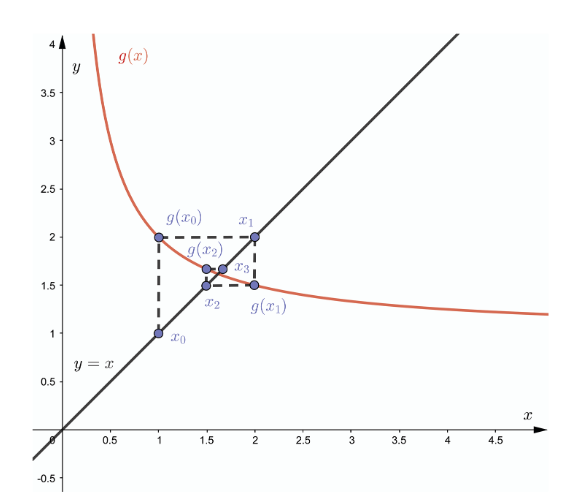
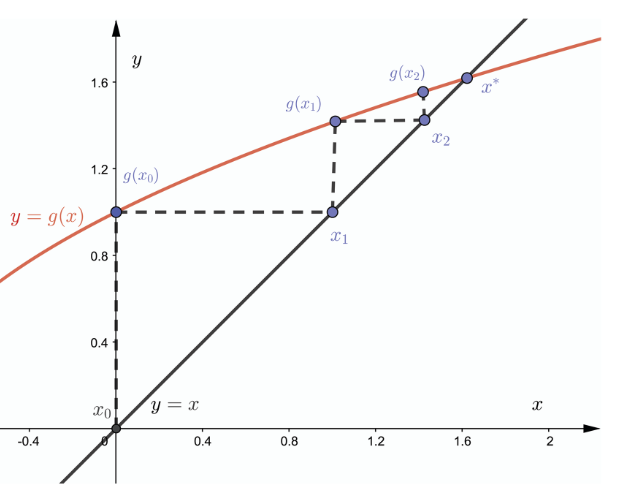

La iteración del punto fijo se visualiza (si converge) como una escalera o telaraña entre y = x y la función y = g(x)

**Como ver:**
1. Partimos de $x_0$ en el eje x
2. Subimos verticalmente hasta y = g(x)
3. Nos movemos horizontamente hasta la recta y = x
4. Repetir el proceso

### _Convergencia_

El orden de convergencia del metodo es lineal.

Si g'(x) = 0, es superlineal (r > 1)

**Si $g'(x) < 1$:**
- La pendiente cerca de la solución debe de ser menor que uno en el valor absoluto.
- El punto fijo es considerado un atractor

**Si $g'(x) > 1$:**
- No se garantiza la convergencia al punto fijo
- El punto fijo no es considerado un repulsor

**Si $g'(x) = 1$:** El punto es considerado un atractor o repulsor en función de sus derivadas superiores

## **<center>2.3 - Metodo de la Newton</center>**

### _Derivación_

Iteración de punto fijo con convergencia cuadratica.

Se aproxima la f(x) mediante su recta tangente en un punto

**Recta Tangente:** $y = f'(x_k)x + b$ con $b = f(x_k) - f'(x_k)x_k$

$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$

**Codigo:**

In [62]:
def newton(f,df,x0, tol=1.e-6,maxit=100,verbose=True):
    
    xk =x0
    x_next = 0
    k = 0
    
    while k < maxit:
        
        fx = f(xk)
        dfx = df(xk)
        if dfx != 0:
            x_next = xk - fx/dfx
            
            error = np.abs(x_next - xk)
            
            if error > tol:
                break
            
            k += 1
            xk = x_next
        
    else:
        print("Maxit reached")
        
    return x_next

In [63]:
def f(x): return np.log(x) + x
def df(x): return 1.0/x + 1.0
x0 = 1.0
tol = 1e-4
maxit = 50
x_root = newton(f, df, x0, tol, maxit)
print('xk: ', x_root)
print('f(xk): ', f(x_root))

xk:  0.5
f(xk):  -0.1931471805599453


## <center>**2.4 - Método de la Secante**</center>

Alternativa al metodo de newton que evita el calculo de derivadas. Se aproxima usando una diferencia finita

$f'(x) = \frac{f(x_k) - f(x_{k-1})}{x_k - x_{k-1}}$

**Interpretación Geometrica:** Linea secante que pasa por los puntos $x_{k-1}$ y $x_k$

**Iteración:** $x_{k+1} = x_k - f(x_k)\frac{x_k - x_{k-1}}{f(x_k) - f(x_{k-1})}$

**Codigo:**

In [64]:
def secante(f,x1,x2,tol=1.e-6,maxit=100,verbose=False):
    
    x_prev = x1
    xk = x2
    x_next = -1
    k = 0
    
    while k < maxit:
        
        fxk = f(xk)
        fprev = f(x_prev)
        
        x_next = xk - fxk*((xk - x_prev)/(fxk - fprev))
        
        error = np.abs(x_next - xk)
        
        if error < tol:
            break
        
        k += 1
        x_prev = xk
        xk = x_next
        
    else:
        print("Maxit reached")
        
    return x_next

In [65]:
def f(x): return np.log(x) + x
x1 = 1.0
x2 = 2.0
tol = 1e-4
maxit = 50
x_root = secante(f, x1, x2, tol, maxit)
print('xk: ', x_root)
print('f(xk): ', f(x_root))

xk:  0.5671432907314143
f(xk):  8.887366398369068e-10
